In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Black-Scholes Formula
def black_scholes(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
    
    return price

# Parameters
S = 100      # Current stock price
K = 105      # Strike price
T = 1        # Time to expiry (1 year)
r = 0.05     # Risk-free rate
sigma = 0.2  # Volatility

call_price = black_scholes(S, K, T, r, sigma, 'call')
put_price = black_scholes(S, K, T, r, sigma, 'put')

print(f"Call Option Price: ${call_price:.2f}")
print(f"Put Option Price: ${put_price:.2f}")

Call Option Price: $8.02
Put Option Price: $7.90


In [2]:
# Monte Carlo Options Pricing
np.random.seed(42)
simulations = 10000

# Simulate stock price paths
z = np.random.standard_normal(simulations)
ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)

# Payoffs
call_payoffs = np.maximum(ST - K, 0)
put_payoffs = np.maximum(K - ST, 0)

# Discounted prices
mc_call = np.exp(-r*T) * np.mean(call_payoffs)
mc_put = np.exp(-r*T) * np.mean(put_payoffs)

print(f"Monte Carlo Call Price: ${mc_call:.2f}")
print(f"Monte Carlo Put Price:  ${mc_put:.2f}")
print(f"Black-Scholes Call:     ${call_price:.2f}")
print(f"Black-Scholes Put:      ${put_price:.2f}")
print(f"\nCall Difference: ${abs(mc_call - call_price):.4f}")
print(f"Put Difference:  ${abs(mc_put - put_price):.4f}")

Monte Carlo Call Price: $8.02
Monte Carlo Put Price:  $7.93
Black-Scholes Call:     $8.02
Black-Scholes Put:      $7.90

Call Difference: $0.0027
Put Difference:  $0.0313


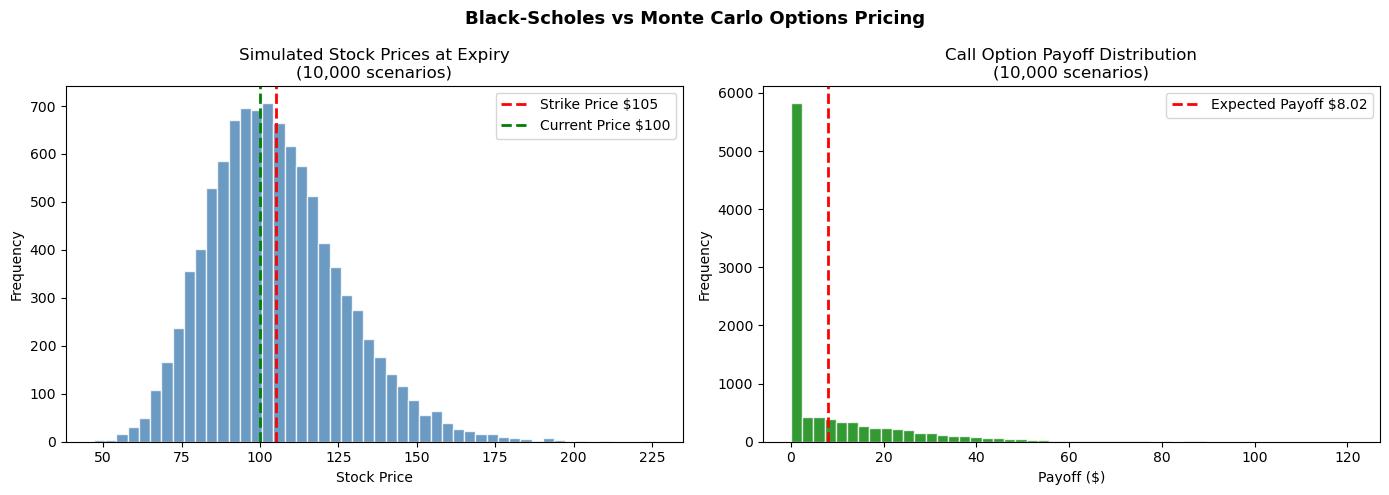


✅ Options Pricing Project Complete!
Black-Scholes & Monte Carlo agree within $0.0027 on call price


In [3]:
# Visualize Stock Price Paths + Payoff Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Simulated stock prices at expiry
ax1.hist(ST, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(K, color='red', linestyle='--', linewidth=2, label=f'Strike Price ${K}')
ax1.axvline(S, color='green', linestyle='--', linewidth=2, label=f'Current Price ${S}')
ax1.set_title('Simulated Stock Prices at Expiry\n(10,000 scenarios)')
ax1.set_xlabel('Stock Price')
ax1.set_ylabel('Frequency')
ax1.legend()

# Plot 2: Call option payoff distribution
ax2.hist(call_payoffs, bins=50, color='green', edgecolor='white', alpha=0.8)
ax2.axvline(mc_call, color='red', linestyle='--', linewidth=2, label=f'Expected Payoff ${mc_call:.2f}')
ax2.set_title('Call Option Payoff Distribution\n(10,000 scenarios)')
ax2.set_xlabel('Payoff ($)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.suptitle('Black-Scholes vs Monte Carlo Options Pricing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('options_pricing.png', dpi=150)
plt.show()

print("\n✅ Options Pricing Project Complete!")
print(f"Black-Scholes & Monte Carlo agree within ${abs(mc_call-call_price):.4f} on call price")